<a href="https://colab.research.google.com/github/fauziah-azzhr/PertemuanKetujuh/blob/main/TugasFrekuensiWavelet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Upload 2 gambar: (1) Natural, (2) Noise Periodik


Saving natural.jpg to natural (4).jpg
Saving noise periodik.jpg to noise periodik (4).jpg


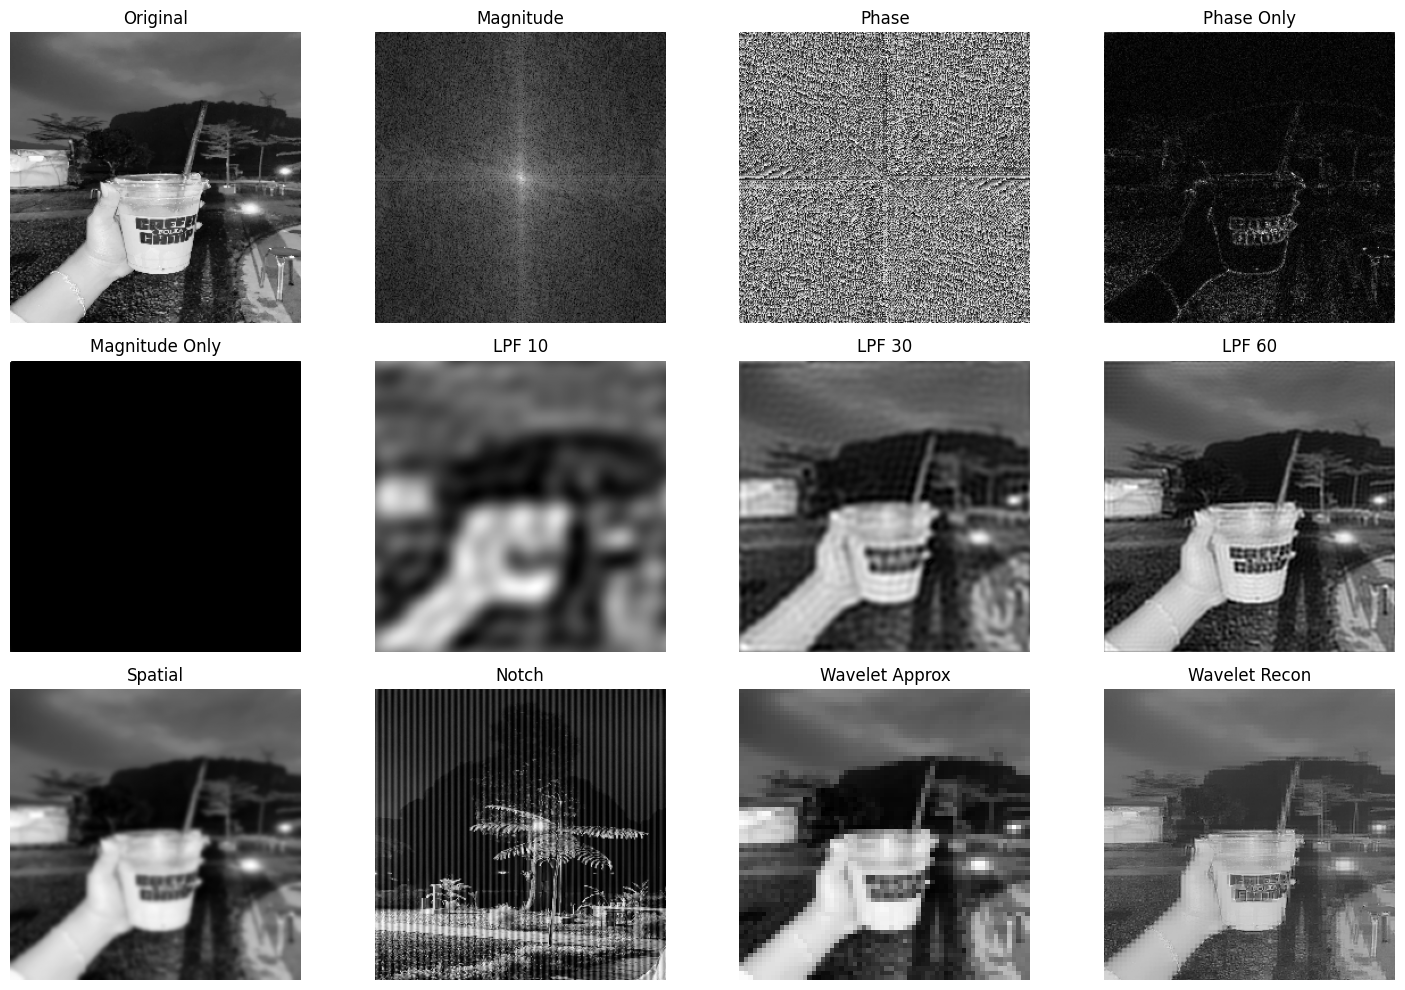


=== TABEL PERBANDINGAN ===
         Metode Cutoff       PSNR  Waktu (detik)
0  Spatial Blur      -  24.718018   2.272129e-04
1     Ideal LPF     10  20.004666   1.192093e-06
2     Ideal LPF     30  23.808221   7.152557e-07
3     Ideal LPF     60  26.910168   4.768372e-07
4  Gaussian LPF     10  21.119057   7.152557e-07
5  Gaussian LPF     30  25.269807   4.768372e-07
6  Gaussian LPF     60  29.556285   4.768372e-07


In [6]:
# =========================================================
# ANALISIS FFT & WAVELET + TABEL PERBANDINGAN
# =========================================================

# 1. IMPORT
# -------------------------------
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import pywt
import time
import pandas as pd
from skimage.metrics import peak_signal_noise_ratio as psnr

# 2. UPLOAD GAMBAR
# -------------------------------
print("Upload 2 gambar: (1) Natural, (2) Noise Periodik")
uploaded = files.upload()
names = list(uploaded.keys())

img1 = cv2.imread(names[0], 0)
img2 = cv2.imread(names[1], 0)

img1 = cv2.resize(img1, (256,256))
img2 = cv2.resize(img2, (256,256))

img1 = img1.astype(np.float32)/255.0
img2 = img2.astype(np.float32)/255.0

# 3. FFT
# -------------------------------
f = np.fft.fft2(img1)
fshift = np.fft.fftshift(f)
magnitude = np.log(np.abs(fshift)+1)
phase = np.angle(fshift)

# 4. REKONSTRUKSI
# -------------------------------
def reconstruct(mag, phase):
    comp = mag * np.exp(1j*phase)
    return np.abs(np.fft.ifft2(np.fft.ifftshift(comp)))

img_phase = reconstruct(np.ones_like(magnitude), phase)
img_mag = reconstruct(magnitude, np.zeros_like(phase))

# 5. FILTER
# -------------------------------
def ideal_lpf(shape, cutoff):
    rows, cols = shape
    mask = np.zeros((rows, cols))
    c = rows//2
    for i in range(rows):
        for j in range(cols):
            if np.sqrt((i-c)**2+(j-c)**2) <= cutoff:
                mask[i,j]=1
    return mask

def gaussian_lpf(shape, cutoff):
    rows, cols = shape
    mask = np.zeros((rows, cols))
    c = rows//2
    for i in range(rows):
        for j in range(cols):
            d = np.sqrt((i-c)**2+(j-c)**2)
            mask[i,j]=np.exp(-(d**2)/(2*(cutoff**2)))
    return mask

def apply_filter(img, mask):
    f = np.fft.fftshift(np.fft.fft2(img))
    filtered = f * mask
    return np.abs(np.fft.ifft2(np.fft.ifftshift(filtered)))

# Variasi cutoff
cutoffs = [10, 30, 60]

results_ilpf = []
results_glpf = []

for c in cutoffs:
    results_ilpf.append(apply_filter(img1, ideal_lpf(img1.shape, c)))
    results_glpf.append(apply_filter(img1, gaussian_lpf(img1.shape, c)))

# 6. FILTER SPASIAL
# -------------------------------
spatial = cv2.GaussianBlur(img1, (9,9), 0)

# 7. NOTCH FILTER
# -------------------------------
def notch(shape):
    mask = np.ones(shape)
    pts = [(128,100),(128,156)]
    for r,c in pts:
        mask[r-5:r+5, c-5:c+5] = 0
    return mask

img_notch = apply_filter(img2, notch(img2.shape))

# 8. WAVELET
# -------------------------------
coeffs = pywt.wavedec2(img1, 'haar', level=2)
cA,(cH,cV,cD),*_ = coeffs

coeffs_new = [cA,(None,None,None)] + coeffs[2:]
img_wave = pywt.waverec2(coeffs_new, 'haar')

# 9. EVALUASI + TABEL
# -------------------------------
data = []

# Spatial
start = time.time()
psnr_val = psnr(img1, spatial, data_range=1.0)
time_val = time.time() - start
data.append(["Spatial Blur", "-", psnr_val, time_val])

# Ideal LPF
for i, c in enumerate(cutoffs):
    start = time.time()
    result = results_ilpf[i]
    t = time.time() - start
    p = psnr(img1, result, data_range=1.0)
    data.append(["Ideal LPF", c, p, t])

# Gaussian LPF
for i, c in enumerate(cutoffs):
    start = time.time()
    result = results_glpf[i]
    t = time.time() - start
    p = psnr(img1, result, data_range=1.0)
    data.append(["Gaussian LPF", c, p, t])

# Buat tabel
df = pd.DataFrame(data, columns=["Metode", "Cutoff", "PSNR", "Waktu (detik)"])

# 10. VISUALISASI
# -------------------------------
plt.figure(figsize=(15,10))

plt.subplot(3,4,1); plt.imshow(img1,cmap='gray'); plt.title("Original"); plt.axis('off')
plt.subplot(3,4,2); plt.imshow(magnitude,cmap='gray'); plt.title("Magnitude"); plt.axis('off')
plt.subplot(3,4,3); plt.imshow(phase,cmap='gray'); plt.title("Phase"); plt.axis('off')
plt.subplot(3,4,4); plt.imshow(img_phase,cmap='gray'); plt.title("Phase Only"); plt.axis('off')

plt.subplot(3,4,5); plt.imshow(img_mag,cmap='gray'); plt.title("Magnitude Only"); plt.axis('off')
plt.subplot(3,4,6); plt.imshow(results_ilpf[0],cmap='gray'); plt.title("LPF 10"); plt.axis('off')
plt.subplot(3,4,7); plt.imshow(results_ilpf[1],cmap='gray'); plt.title("LPF 30"); plt.axis('off')
plt.subplot(3,4,8); plt.imshow(results_ilpf[2],cmap='gray'); plt.title("LPF 60"); plt.axis('off')

plt.subplot(3,4,9); plt.imshow(spatial,cmap='gray'); plt.title("Spatial"); plt.axis('off')
plt.subplot(3,4,10); plt.imshow(img_notch,cmap='gray'); plt.title("Notch"); plt.axis('off')
plt.subplot(3,4,11); plt.imshow(cA,cmap='gray'); plt.title("Wavelet Approx"); plt.axis('off')
plt.subplot(3,4,12); plt.imshow(img_wave,cmap='gray'); plt.title("Wavelet Recon"); plt.axis('off')

plt.tight_layout()
plt.show()

# 11. TABEL OUTPUT
# -------------------------------
print("\n=== TABEL PERBANDINGAN ===")
print(df)